In [ ]:
import os
import sys

sys.path.append("../")
from data import NiiPoint, BaseTfmLibrary as tfm_base, DataTfmLibrary as tfm_data
import json

os.environ["CUDA_VISIBLE_DEVICES"] = "0"
source_dir = "../nnUNet_raw/Dataset/"
target_dir = "../nnUNet_raw/Dataset_val/"
val_split = 0.2

## Data source
img_test_dir = os.path.join(source_dir, "imagesTs")
lab_test_dir = os.path.join(source_dir, "labelsTs")

img_train_dir = os.path.join(source_dir, "imagesTr")
lab_train_dir = os.path.join(source_dir, "labelsTr")

# Data target
target_img_test_dir = os.path.join(target_dir, "imagesTs")
target_lab_test_dir = os.path.join(target_dir, "labelsTs")

target_img_train_dir = os.path.join(target_dir, "imagesTr")
target_lab_train_dir = os.path.join(target_dir, "labelsTr")

target_img_val_dir = os.path.join(target_dir, "imagesVl")
target_lab_val_dir = os.path.join(target_dir, "labelsVl")

for dir_i in [
    target_img_test_dir,
    target_lab_test_dir,
    target_img_train_dir,
    target_lab_train_dir,
    target_img_val_dir,
    target_lab_val_dir,
]:
    os.makedirs(dir_i, exist_ok=True)
    

def process_data(img_path, lab_path, target_img_path, target_lab_path):
    ncct_data = NiiPoint.from_path(img_path, "cuda")
    cta_data = NiiPoint.from_path(lab_path, "cuda")

    ncct_norm = tfm_data.ncct_normalization_tfm(ncct_data)
    vess_norm = tfm_data.vessel_normalization_tfm(
        tfm_data.vessel_tfm(ncct_data, cta_data)
    )

    ncct_norm.save_to_path(target_img_path)
    vess_norm.save_to_path(target_lab_path)
    return ncct_norm, vess_norm


def cases_from_dir(images_dir):
    files = os.listdir(images_dir)
    cases = [file[:9] for file in files]
    return cases


for file in cases_from_dir(img_test_dir):
    print(f"Processing {file}...", end="\r")
    process_data(
        os.path.join(img_test_dir, f"{file}_0000.nii.gz"),
        os.path.join(lab_test_dir, f"{file}_0001.nii.gz"),
        os.path.join(target_img_test_dir, f"{file}_0000.nii.gz"),
        os.path.join(target_lab_test_dir, f"{file}_0001.nii.gz"),
    )
    


for i, file in enumerate(cases_from_dir(img_train_dir)):
    print(f"Processing {file}...", end="\r")
    if i < int(len(cases_from_dir(img_train_dir)) * (1 - val_split)):
        process_data(
            os.path.join(img_train_dir, f"{file}_0000.nii.gz"),
            os.path.join(lab_train_dir, f"{file}_0001.nii.gz"),
            os.path.join(target_img_train_dir, f"{file}_0000.nii.gz"),
            os.path.join(target_lab_train_dir, f"{file}_0001.nii.gz"),
        )
    else:
        process_data(
            os.path.join(img_train_dir, f"{file}_0000.nii.gz"),
            os.path.join(lab_train_dir, f"{file}_0001.nii.gz"),
            os.path.join(target_img_val_dir, f"{file}_0000.nii.gz"),
            os.path.join(target_lab_val_dir, f"{file}_0001.nii.gz"),
        )
        


dataset_json = {
    "channel_names": {
        "0": "NCCT_norm",
        "1": "VSL_norm"
    },
    "numTraining": len(os.listdir(target_img_train_dir)),
    "numTest": len(os.listdir(target_img_test_dir)),
    "numValidation": len(os.listdir(target_img_val_dir)),
    "file_ending": ".nii.gz",
    "val_split": val_split,
}

with open(os.path.join(target_dir, "dataset.json"), "w") as f:
    json.dump(dataset_json, f, indent=4)

<Axes: title={'center': 'Z Slice'}>

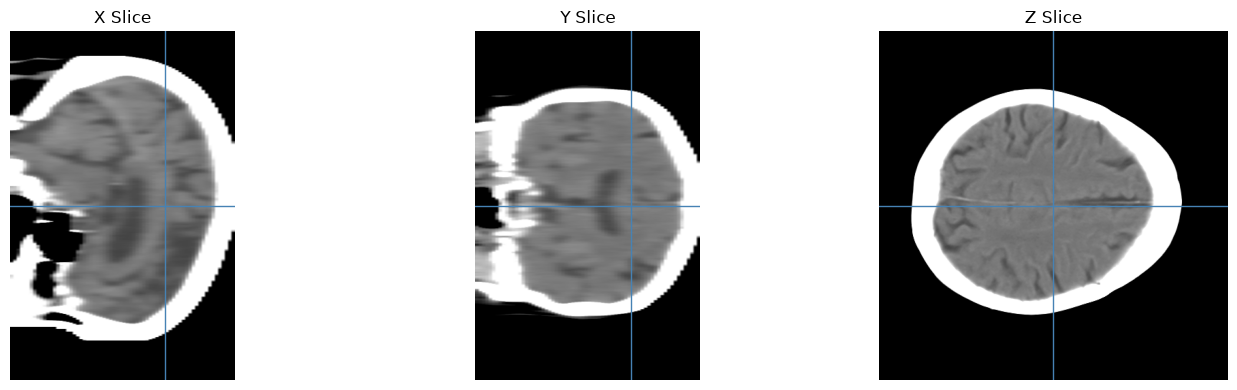

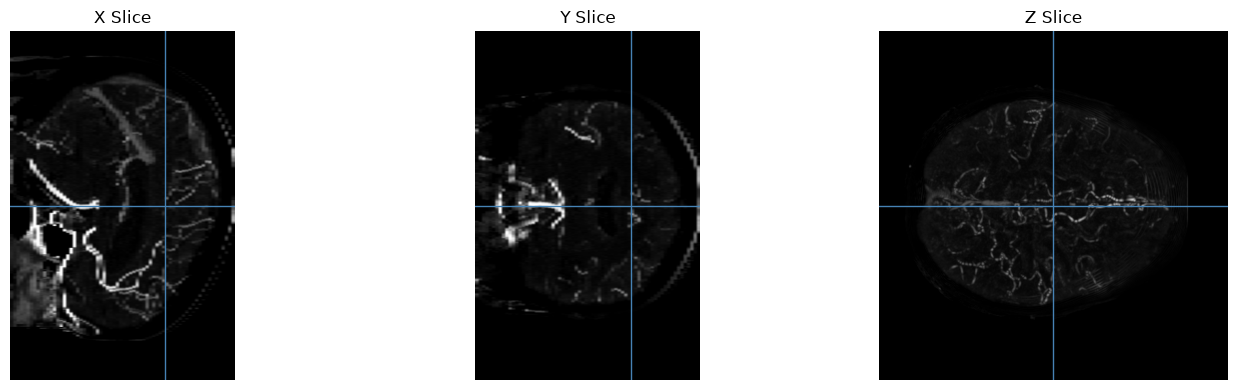

In [ ]:
id = 102
id = str(id).zfill(4)
data = NiiPoint.from_path(os.path.join(target_dir, "imagesTr", f"case_{id}_0000.nii.gz"), "cuda")
label = NiiPoint.from_path(os.path.join(target_dir, "labelsTr", f"case_{id}_0001.nii.gz"), "cuda")

data.plot_slices((0.5, 0.5, 0.7), (1, 1, 1), vmin=-1.0, vmax=1.0, cmap="gray")
label.plot_slices((0.5, 0.5, 0.7), (10, 10, 10), vmin=-1.0, vmax=1.0, cmap="gray")
